In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from types import SimpleNamespace
from tabulate import tabulate

In [9]:
# Set constants
RISK_FREE_RATE = 0.04
MAX_DRAWDOWN = 0.25
TRADING_DAYS = 252

# Load CSV data and convert date column
try:
    df = pd.read_csv("sp500_10s.csv")
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
except Exception as e:
    raise RuntimeError(f"Failed to load or parse data: {e}")


In [10]:
# Pivot table so rows = dates and columns = stock names
price_df = df.pivot(index="date", columns="Name", values="close")

# Calculate daily returns
returns = price_df.pct_change().dropna(how='all')

# Calculate annualised return, volatility and Sharpe ratio
annual_returns = returns.mean() * TRADING_DAYS
annual_vol = returns.std() * np.sqrt(TRADING_DAYS)
sharpe_ratios = (annual_returns - RISK_FREE_RATE) / (annual_vol.replace(0, np.nan) + 1e-8)

# Pick top 10 assets by Sharpe ratio
top_assets = sharpe_ratios.nlargest(10).dropna().index.tolist()

# Clean price data for selected assets
price_data = price_df[top_assets].ffill().bfill()
returns = price_data.pct_change().dropna()
tickers = returns.columns.tolist()
mean_returns = returns.mean() * TRADING_DAYS
cov_matrix = returns.cov() * TRADING_DAYS

In [11]:
# Calculate portfolio return, volatility, and Sharpe ratio
def portfolio_performance(weights):
    weights = np.clip(weights, 0, 1)
    weights /= weights.sum() + 1e-8
    port_return = np.dot(weights, mean_returns)
    port_vol = np.sqrt(weights.T @ cov_matrix @ weights)
    sharpe = (port_return - RISK_FREE_RATE) / (port_vol + 1e-8)
    return port_return, port_vol, sharpe

# Penalise portfolios with drawdowns above the limit
def drawdown_penalty(weights):
    try:
        portfolio_values = (price_data @ weights).pct_change().dropna()
        cumulative = (1 + portfolio_values).cumprod()
        peak = cumulative.expanding().max()
        drawdown = (peak - cumulative) / peak
        return 1e3 * max(0, drawdown.max() - MAX_DRAWDOWN)
    except Exception:
        return 1e6  # Apply a heavy penalty if drawdown calc fails

In [12]:
# Particle Swarm Optimisation for portfolio weights
class PSOOptimizer:
    def __init__(self, objective, num_assets, n_trials=3, n_particles=100, max_iter=200):
        self.objective = objective
        self.num_assets = num_assets
        self.n_trials = n_trials
        self.n_particles = n_particles
        self.max_iter = max_iter

    class Particle:
        def __init__(self, num_assets):
            self.weights = np.random.dirichlet(np.ones(num_assets))
            self.velocity = np.zeros(num_assets)
            self.best_weights = self.weights.copy()
            self.best_score = float('inf')

    def optimize(self):
        global_best = {'weights': None, 'score': float('inf')}
        for _ in range(self.n_trials):
            swarm = [self.Particle(self.num_assets) for _ in range(self.n_particles)]
            for iter_ in range(self.max_iter):
                for particle in swarm:
                    inertia = 0.9 - (0.5 * iter_ / self.max_iter)
                    cognitive = 1.5 * np.random.rand()
                    social = 1.5 * np.random.rand()
                    if global_best['weights'] is not None:
                        social_component = social * (global_best['weights'] - particle.weights)
                    else:
                        social_component = 0
                    particle.velocity = (
                        inertia * particle.velocity +
                        cognitive * (particle.best_weights - particle.weights) +
                        social_component
                    )
                    particle.weights = np.clip(particle.weights + particle.velocity, 0, 1)
                    particle.weights /= particle.weights.sum() + 1e-8
                    try:
                        score = self.objective(particle.weights)
                    except Exception:
                        score = 1e6  # Fallback penalty
                    if score < particle.best_score:
                        particle.best_score = score
                        particle.best_weights = particle.weights.copy()
                        if score < global_best['score']:
                            global_best['score'] = score
                            global_best['weights'] = particle.weights.copy()
        result = SimpleNamespace()
        result.x = global_best['weights']
        result.fun = global_best['score']
        return result

In [6]:
# Define optimisation objectives
objectives = {
    'max_sharpe': lambda w: -portfolio_performance(w)[2] + drawdown_penalty(w),
    'min_vol': lambda w: portfolio_performance(w)[1] + drawdown_penalty(w)
}

# Run PSO for each objective
results = {}
for name, obj in objectives.items():
    try:
        opt = PSOOptimizer(obj, len(tickers))
        results[name] = opt.optimize()
    except Exception as e:
        raise RuntimeError(f"PSO optimisation failed for {name}: {e}")


=== Optimal Portfolio Allocation ===
| Asset   |   Max Sharpe (%) |   Min Volatility (%) |
|---------|------------------|----------------------|
| NFLX    |            22.3  |                 0.34 |
| AMZN    |            20.3  |                 0.16 |
| V       |            20.56 |                 4.03 |
| MSFT    |            19.58 |                 3.67 |
| GOOGL   |             3.25 |                 5.15 |
| BAC     |             3.71 |                 3.47 |
| AAPL    |             5.06 |                10.06 |
| JNJ     |             5.24 |                44.65 |
| WMT     |             0    |                27.63 |
| CHK     |             0    |                 0.83 |

=== Performance Metrics ===
+----------------+--------+------------+--------------+
|   Portfolio    | Return | Volatility | Sharpe Ratio |
+----------------+--------+------------+--------------+
|   Max Sharpe   | 33.49% |   19.15%   |     1.54     |
| Min Volatility | 13.82% |   11.92%   |     0.82     |
+----

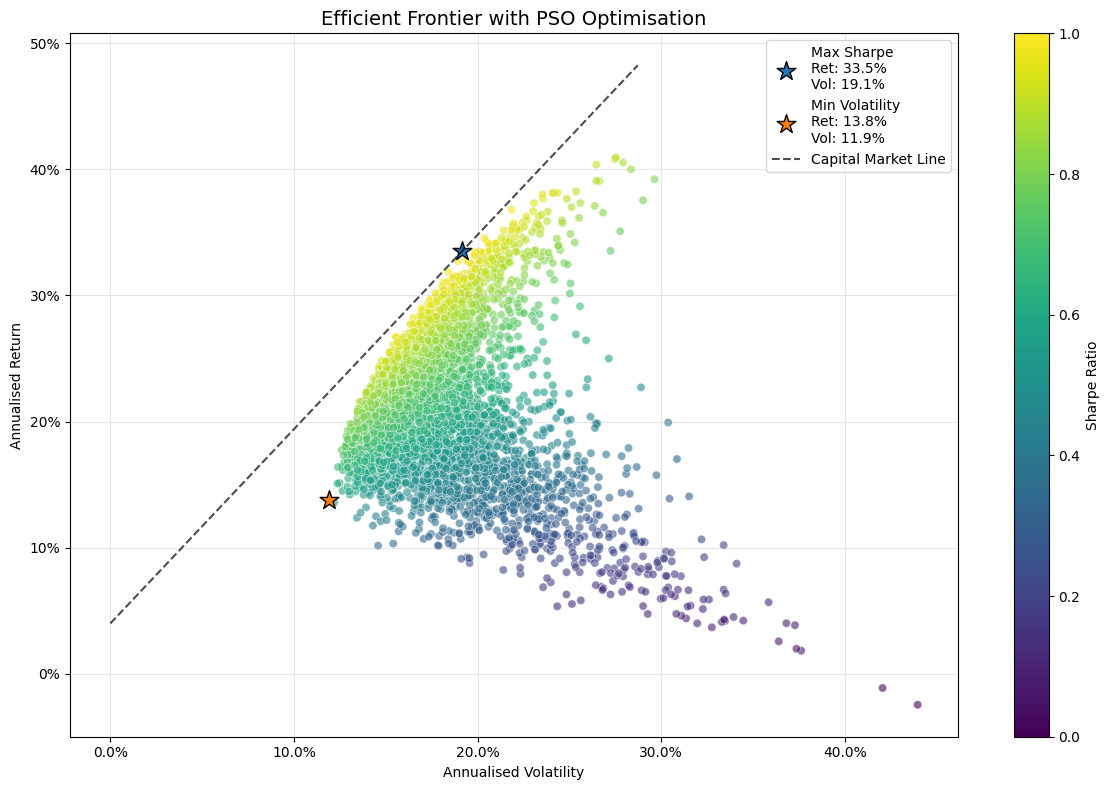

In [7]:
# Print allocation results
print("\n=== Optimal Portfolio Allocation ===")
alloc_df = pd.DataFrame({
    'Asset': tickers,
    'Max Sharpe (%)': [f"{w*100:.2f}" for w in results['max_sharpe'].x],
    'Min Volatility (%)': [f"{w*100:.2f}" for w in results['min_vol'].x]
})
print(tabulate(alloc_df, headers='keys', tablefmt='github', showindex=False))

# Print portfolio performance metrics
print("\n=== Performance Metrics ===")
metrics = []
for label, key in [('Max Sharpe', 'max_sharpe'), ('Min Volatility', 'min_vol')]:
    try:
        ret, vol, sharpe = portfolio_performance(results[key].x)
        metrics.append([label, f"{ret:.2%}", f"{vol:.2%}", f"{sharpe:.2f}"])
    except Exception:
        metrics.append([label, "N/A", "N/A", "N/A"])
print(tabulate(metrics, headers=['Portfolio', 'Return', 'Volatility', 'Sharpe Ratio'], tablefmt='pretty'))

# Simulate portfolios for plotting
try:
    weights_sim = np.random.dirichlet(np.ones(len(tickers)), 5000)
    returns_sim = weights_sim @ mean_returns
    vols_sim = np.sqrt(np.einsum('...i,ij,...j->...', weights_sim, cov_matrix, weights_sim))
    sharpe_sim = (returns_sim - RISK_FREE_RATE) / vols_sim
except Exception as e:
    raise RuntimeError(f"Simulation failed: {e}")

# Plot efficient frontier and optimal points
try:
    plt.figure(figsize=(12, 8))
    plt.scatter(vols_sim, returns_sim, c=sharpe_sim, cmap='viridis', alpha=0.6, edgecolors='w', linewidth=0.5)

    # Highlight optimal portfolios
    for label, key in [('Max Sharpe', 'max_sharpe'), ('Min Volatility', 'min_vol')]:
        w = results[key].x
        ret, vol, _ = portfolio_performance(w)
        plt.scatter(vol, ret, s=200, marker='*', edgecolor='black', label=f'{label}\nRet: {ret:.1%}\nVol: {vol:.1%}')

    # Plot capital market line
    opt_ret, opt_vol, _ = portfolio_performance(results['max_sharpe'].x)
    cml_x = np.linspace(0, opt_vol * 1.5)
    cml_y = RISK_FREE_RATE + (opt_ret - RISK_FREE_RATE) / opt_vol * cml_x
    plt.plot(cml_x, cml_y, 'k--', lw=1.5, alpha=0.7, label='Capital Market Line')

    # Final plot formatting
    plt.gca().xaxis.set_major_formatter(PercentFormatter(1.0))
    plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
    plt.title('Efficient Frontier with PSO Optimisation', fontsize=14)
    plt.xlabel('Annualised Volatility')
    plt.ylabel('Annualised Return')
    plt.colorbar(label='Sharpe Ratio')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Plotting failed: {e}")